In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [21]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df["target"] = y

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (150, 5)

First 5 Rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [24]:
logistic_model = LogisticRegression(max_iter=200)

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

In [25]:
# Logistic Regression
logistic_model.fit(X_train_scaled, y_train)

# Decision Tree
decision_tree_model.fit(X_train, y_train)

# KNN
knn_model.fit(X_train_scaled, y_train)

print("All models trained successfully.")

All models trained successfully.


In [26]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

y_pred_tree = decision_tree_model.predict(X_test)

y_pred_knn = knn_model.predict(X_test_scaled)

print("Predictions completed successfully.")

Predictions completed successfully.


In [27]:
models = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "KNN": y_pred_knn
}

results = []

for model_name, y_pred in models.items():

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )
    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )
    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

results_df[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
] = results_df[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
] * 100

print(results_df.round(2))

             Algorithm  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     93.33      93.33   93.33     93.33
1        Decision Tree     93.33      93.33   93.33     93.33
2                  KNN     93.33      94.44   93.33     93.27


In [28]:
for model_name, y_pred in models.items():
    cm = confusion_matrix(y_test, y_pred)
    print("\n" + "-" * 50)
    print(model_name)
    print(cm)


--------------------------------------------------
Logistic Regression
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

--------------------------------------------------
Decision Tree
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

--------------------------------------------------
KNN
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


In [29]:
for model_name, y_pred in models.items():
    print("\n" + "-" * 60)
    print(model_name)
    print("-" * 60)
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=iris.target_names
        )
    )


------------------------------------------------------------
Logistic Regression
------------------------------------------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


------------------------------------------------------------
Decision Tree
------------------------------------------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg 

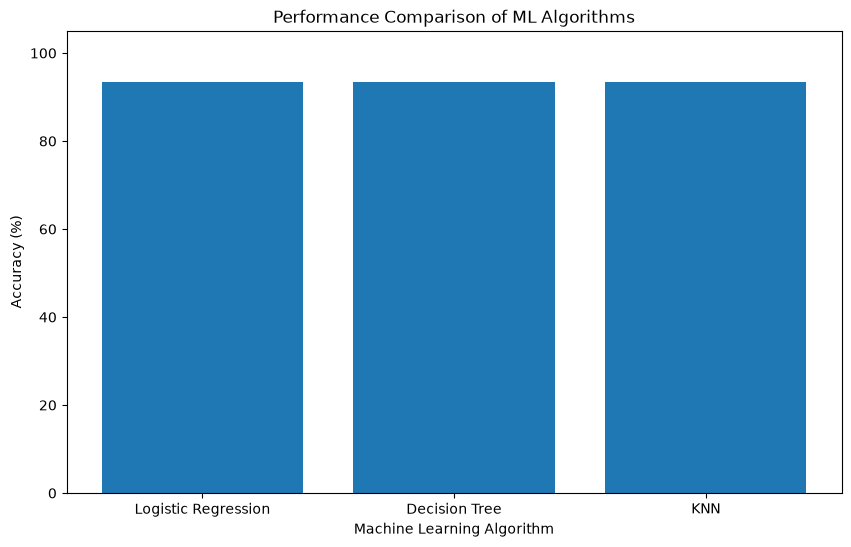

In [30]:
plt.figure(figsize=(10, 6))
plt.bar(
    results_df["Algorithm"],
    results_df["Accuracy"]
)
plt.xlabel("Machine Learning Algorithm")
plt.ylabel("Accuracy (%)")
plt.title("Performance Comparison of ML Algorithms")
plt.ylim(0, 105)
plt.show()

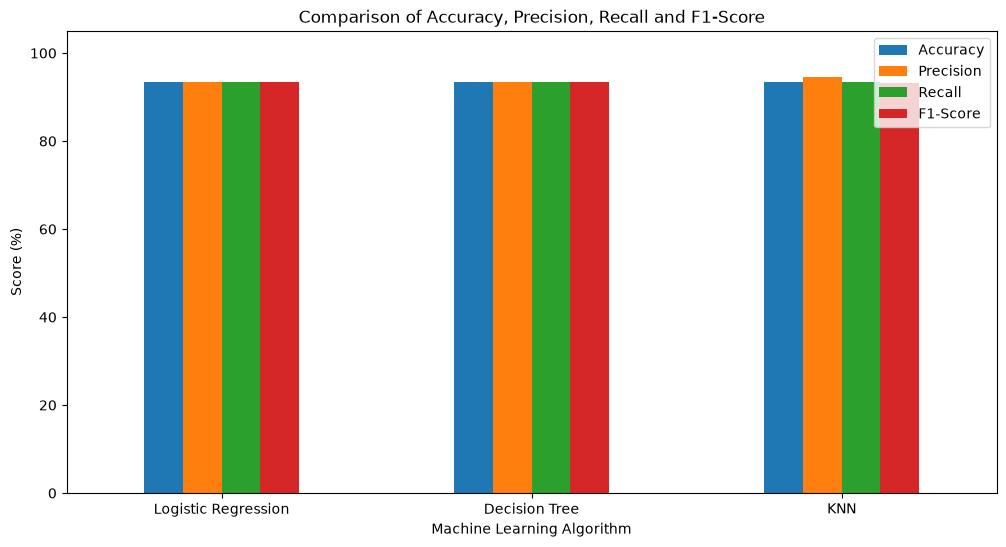

In [31]:
results_df.set_index("Algorithm")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)
plt.xlabel("Machine Learning Algorithm")
plt.ylabel("Score (%)")
plt.title("Comparison of Accuracy, Precision, Recall and F1-Score")
plt.ylim(0, 105)
plt.xticks(rotation=0)
plt.show()

In [32]:
best_model = results_df.loc[
    results_df["F1-Score"].idxmax()
]
print("Best Performing Algorithm:")
print(best_model["Algorithm"])
print("\nPerformance:")
print("Accuracy :", round(best_model["Accuracy"], 2), "%")
print("Precision:", round(best_model["Precision"], 2), "%")
print("Recall   :", round(best_model["Recall"], 2), "%")
print("F1-Score :", round(best_model["F1-Score"], 2), "%")

Best Performing Algorithm:
Logistic Regression

Performance:
Accuracy : 93.33 %
Precision: 93.33 %
Recall   : 93.33 %
F1-Score : 93.33 %


In [33]:
print("\nFinal Performance Comparison")
print("-" * 70)
print(results_df.round(2).to_string(index=False))


Final Performance Comparison
----------------------------------------------------------------------
          Algorithm  Accuracy  Precision  Recall  F1-Score
Logistic Regression     93.33      93.33   93.33     93.33
      Decision Tree     93.33      93.33   93.33     93.33
                KNN     93.33      94.44   93.33     93.27
